In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, GridSearchCV
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Landslide project/Random forest/actual_location_three_node_labeling.csv')

In [ ]:
df.head()

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,sand,silt,clay,label
0,45:26.0,106,0.000000,0.0,36.700001,57.799999,0.0,0.0,0.0,70.52,4,24.48,NaN
1,47:14.5,106,1.597111,0.0,36.900002,61.500000,0.0,0.0,0.0,70.52,4,24.48,NaN
2,49:02.2,106,0.000000,0.0,36.900002,61.099998,0.0,0.0,0.0,70.52,4,24.48,NaN
3,49:46.6,106,1.604698,0.0,36.900002,60.099998,0.0,-1.0,-1.0,70.52,4,24.48,NaN
4,50:32.1,106,1.604698,0.0,36.750000,60.699999,0.5,-1.0,-1.0,70.52,4,24.48,NaN


In [ ]:
df['label'] = df['label'].fillna('normal')

In [ ]:
print(df)

     timestamp  devID       soil    rain       temp       humi       geo  \
0      45:26.0    106   0.000000  0.0000  36.700001  57.799999  0.000000   
1      47:14.5    106   1.597111  0.0000  36.900002  61.500000  0.000000   
2      49:02.2    106   0.000000  0.0000  36.900002  61.099998  0.000000   
3      49:46.6    106   1.604698  0.0000  36.900002  60.099998  0.000000   
4      50:32.1    106   1.604698  0.0000  36.750000  60.699999  0.500000   
...        ...    ...        ...     ...        ...        ...       ...   
3595   58:26.4    109  26.400000  0.5588  30.050000  77.550003  0.473718   
3596   59:16.3    109  26.400000  0.5588  30.100000  72.800003  0.861036   
3597   59:56.6    109  26.400000  0.5588  30.100000  72.800003  0.861036   
3598   00:42.3    109  26.400000  0.5588  30.500000  74.800003  0.770792   
3599   01:31.6    109  26.400000  0.6985  30.750000  74.750000  0.761907   

           lat        lng   sand  silt   clay   label  
0     0.000000   0.000000  70.5

In [ ]:
feature_column=['soil','rain','temp','humi','geo','sand','silt','clay']
target_column='label'
x=df[feature_column]
y=df[target_column]

In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
print(f"\nData split complete")
print(f"Training set has {X_train.shape[0]} samples")
print(f"Testing set has {X_test.shape[0]} samples")
print("\nTraining set label distribution:")
print(y_train.value_counts())


Data split complete
Training set has 2880 samples
Testing set has 720 samples

Training set label distribution:
label
normal      2676
warning      148
critical      56
Name: count, dtype: int64


In [ ]:
import joblib

model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Training the model... ⏳")
model.fit(X_train, y_train)
print("Model training complete! ✅")

# Define the path to save the model in Google Drive
model_path = '/content/drive/MyDrive/Landslide project/Random forest/random_forest_model.joblib'

# Save the trained model
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Training the model... ⏳
Model training complete! ✅
Model saved to /content/drive/MyDrive/Landslide project/Random forest/random_forest_model.joblib


In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n--- Model Performance Metrics ---")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


--- Model Performance Metrics ---
Accuracy: 0.994
Precision: 0.994
Recall: 0.994
F1 Score: 0.994
Classification Report:
               precision    recall  f1-score   support

    critical       1.00      1.00      1.00        14
      normal       1.00      1.00      1.00       669
     warning       0.97      0.92      0.94        37

    accuracy                           0.99       720
   macro avg       0.99      0.97      0.98       720
weighted avg       0.99      0.99      0.99       720



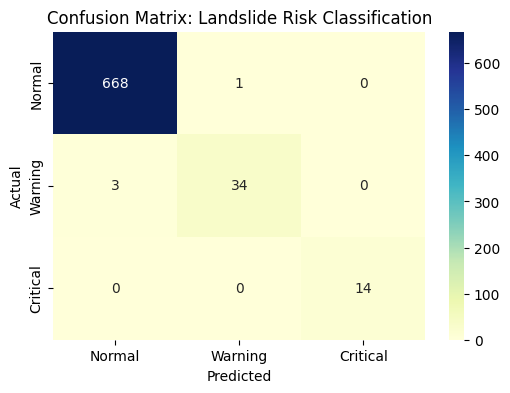

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=['normal','warning','critical'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Normal", "Warning", "Critical"],
            yticklabels=["Normal", "Warning", "Critical"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Landslide Risk Classification")
plt.show()

In [ ]:
import joblib

In [ ]:
loaded_model_path = '/content/drive/MyDrive/Landslide project/Random forest/random_forest_model.joblib'
loaded_model = joblib.load(loaded_model_path)

print(f"Model loaded from {loaded_model_path}")

Model loaded from /content/drive/MyDrive/Landslide project/Random forest/random_forest_model.joblib


In [209]:
new_data_ =pd.read_csv("/content/drive/MyDrive/Landslide project/Random forest/devID_109_label.csv")
new_data_df1 = pd.DataFrame(new_data_)
print("\nNew data for inference:")
display(new_data_df1)


New data for inference:


,soil,rain,temp,humi,geo,iso_risk,lstm_risk,rf,label
0,24.550000,0.0000,32.950001,66.000000,1.865759,0,0,0,NaN
1,24.600000,0.0000,32.700001,70.300003,0.698611,0,0,0,NaN
2,24.600000,0.0000,32.700001,70.300003,0.698611,0,0,0,NaN
3,24.600000,0.0000,32.400002,68.300003,3.730135,0,0,0,NaN
4,24.600000,0.0000,32.400002,68.950001,13.334469,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...
10751,31.849999,0.0000,27.299999,92.150002,0.499649,0,0,0,NaN
10752,31.799999,0.2794,27.400000,91.300003,29.169378,1,0,1,NaN
10753,31.799999,0.2794,27.400000,91.300003,10.384488,0,0,1,NaN
10754,31.799999,0.2794,27.400000,91.300003,10.384488,0,0,1,NaN


In [210]:
new_data_df1['sand'] = 30
new_data_df1['silt'] = 10
new_data_df1['clay'] = 60
print("Added 'sand', 'silt', and 'clay' columns to new_data_df1 with default values.")

Added 'sand', 'silt', and 'clay' columns to new_data_df1 with default values.


Columns in new_data_df1: Index(['soil', 'rain', 'temp', 'humi', 'geo', 'iso_risk', 'lstm_risk', 'rf',
       'label', 'sand', 'silt', 'clay'],
      dtype='object')

--- Model Performance Metrics on New Data (new_data_df1) ---
Accuracy: 0.999
Precision: 0.999
Recall: 0.999
F1 Score: 0.999
Classification Report:
               precision    recall  f1-score   support

    critical       0.98      0.96      0.97        48
      normal       1.00      1.00      1.00     10683
     warning       0.81      1.00      0.89        25

    accuracy                           1.00     10756
   macro avg       0.93      0.99      0.95     10756
weighted avg       1.00      1.00      1.00     10756



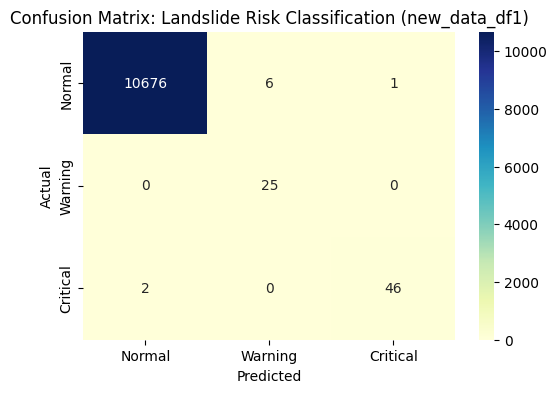

In [211]:
print("Columns in new_data_df1:", new_data_df1.columns)

# Check if 'label' column exists, if not, handle it
if 'label' not in new_data_df1.columns:
    print("\n'label' column not found in new_data_df1. Please identify the correct column for ground truth labels.")
    print("If a column contains the true labels, rename it to 'label' like this:")
    print("# new_data_df1 = new_data_df1.rename(columns={'Your_Actual_Label_Column_Name': 'label'})\n")

    # Add a dummy 'label' column to prevent KeyError and allow the code to run,
    # but warn the user that evaluation metrics will be inaccurate.
    new_data_df1['label'] = 'normal' # Default to 'normal' or any valid class
    print("A dummy 'label' column initialized to 'normal' has been added to proceed with execution. ")
    print("Performance metrics will be inaccurate without actual ground truth labels, please update the 'label' column.")

# Fill missing values in the 'label' column with 'normal'
new_data_df1['label'] = new_data_df1['label'].fillna('normal')

# Use the 'label' column from new_data_df1 as the true labels for evaluation
y_true_new1 = new_data_df1['label']

# Scale the new data (new_data_df1) using the same scaler fitted on the training data
# Make sure the 'scaler' object from the training phase is available
new_data_scaled1 = scaler.transform(new_data_df1[feature_column])

# Make predictions on the scaled new data (new_data_df1)
y_pred_new1 = loaded_model.predict(new_data_scaled1)

# Calculate and display performance metrics
accuracy_new1 = accuracy_score(y_true_new1, y_pred_new1)
precision_new1 = precision_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
recall_new1 = recall_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
f1_new1 = f1_score(y_true_new1, y_pred_new1, average='weighted', zero_division=0)
cm_new1 = confusion_matrix(y_true_new1, y_pred_new1, labels=['normal', 'warning', 'critical'])


print("\n--- Model Performance Metrics on New Data (new_data_df1) ---")
print("Accuracy:", round(accuracy_new1, 3))
print("Precision:", round(precision_new1, 3))
print("Recall:", round(recall_new1, 3))
print("F1 Score:", round(f1_new1, 3))
print("Classification Report:\n", classification_report(y_true_new1, y_pred_new1, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_new1, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Normal", "Warning", "Critical"],
            yticklabels=["Normal", "Warning", "Critical"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Landslide Risk Classification (new_data_df1)")
plt.show()